# Streamline Variability Exploration

This notebook explores the 2004 MN4 variant SPICE kernels one step at a time. Start with one kernel, verify the target ID and coverage, then plot a single trajectory before overlaying more variants.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import spiceypy as spice

try:
    import ipympl  # noqa: F401
    get_ipython().run_line_magic("matplotlib", "widget")
except ModuleNotFoundError:
    print("Install ipympl for rotatable 3D plots in JupyterLab: python -m pip install ipympl")
    get_ipython().run_line_magic("matplotlib", "inline")


cwd = Path.cwd().resolve()
if (cwd / "data").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "data").exists():
    REPO_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find repo root. Start JupyterLab from NEOviz_repo or revision.")

KERNEL_DIR = REPO_ROOT / "data" / "B612_data" / "Test" / "2004 MN4" / "variant_kernels"
FIRST_VARIANT_KERNEL = KERNEL_DIR / "000001.bsp"

LSK_KERNEL = REPO_ROOT / "data" / "kernels" / "lsk" / "naif0012.tls.pc"
SPK_KERNEL = REPO_ROOT / "data" / "kernels" / "spk" / "de432s.bsp"
PCK_KERNEL = REPO_ROOT / "data" / "kernels" / "pck" / "pck00011.tpc"

START_TIME = "2029 APR 13 14:00:00"
END_TIME = "2029 APR 14 02:00:00"
SAMPLE_INTERVAL_SECONDS = 900.0

print("Repo root:", REPO_ROOT)
print("Variant kernel directory:", KERNEL_DIR)
print("First variant kernel:", FIRST_VARIANT_KERNEL)
print("Number of variant kernels:", len(list(KERNEL_DIR.glob("*.bsp"))))

Repo root: /mnt/c/Users/flan/Documents/NEOviz/NEOviz_repo
Variant kernel directory: /mnt/c/Users/flan/Documents/NEOviz/NEOviz_repo/data/B612_data/Test/2004 MN4/variant_kernels
First variant kernel: /mnt/c/Users/flan/Documents/NEOviz/NEOviz_repo/data/B612_data/Test/2004 MN4/variant_kernels/000001.bsp
Number of variant kernels: 1000


## Inspect One Kernel

Load the core SPICE kernels plus one variant kernel. Then read the object ID and time coverage from `000001.bsp`.

In [2]:
spice.kclear()
spice.furnsh(str(LSK_KERNEL))
spice.furnsh(str(SPK_KERNEL))
spice.furnsh(str(PCK_KERNEL))
spice.furnsh(str(FIRST_VARIANT_KERNEL))

object_ids = sorted(spice.spkobj(str(FIRST_VARIANT_KERNEL)))
print("Object IDs in first variant kernel:", object_ids)

target_id = str(object_ids[0])
coverage_windows = spice.spkcov(str(FIRST_VARIANT_KERNEL), object_ids[0])

print("Using target ID:", target_id)
print("Coverage intervals:")
for i in range(0, len(coverage_windows), 2):
    start = spice.et2utc(coverage_windows[i], "ISOC", 3)
    end = spice.et2utc(coverage_windows[i + 1], "ISOC", 3)
    print(" ", start, "to", end)

Object IDs in first variant kernel: [1000000]
Using target ID: 1000000
Coverage intervals:
  2004-12-27T02:58:30.001 to 2029-04-30T00:00:00.000


## Sample One Trajectory

Sample from April 13, 2029 at 14:00:00 to April 14, 2029 at 02:00:00. Positions are relative to the Sun in the J2000 frame.

In [3]:
start_et = spice.str2et(START_TIME)
end_et = spice.str2et(END_TIME)
times_et = np.arange(start_et, end_et + 0.5 * SAMPLE_INTERVAL_SECONDS, SAMPLE_INTERVAL_SECONDS)

positions_km, light_times = spice.spkpos(
    target_id,
    times_et,
    "J2000",
    "NONE",
    "SUN",
)
positions_km = np.asarray(positions_km)

print("Sampled positions shape:", positions_km.shape)
print("First sampled position, km:", positions_km[0])
print("Last sampled position, km:", positions_km[-1])

Sampled positions shape: (49, 3)
First sampled position, km: [-1.37762373e+08 -5.49422204e+07 -2.38654106e+07]
Last sampled position, km: [-1.37057343e+08 -5.59090447e+07 -2.42022389e+07]


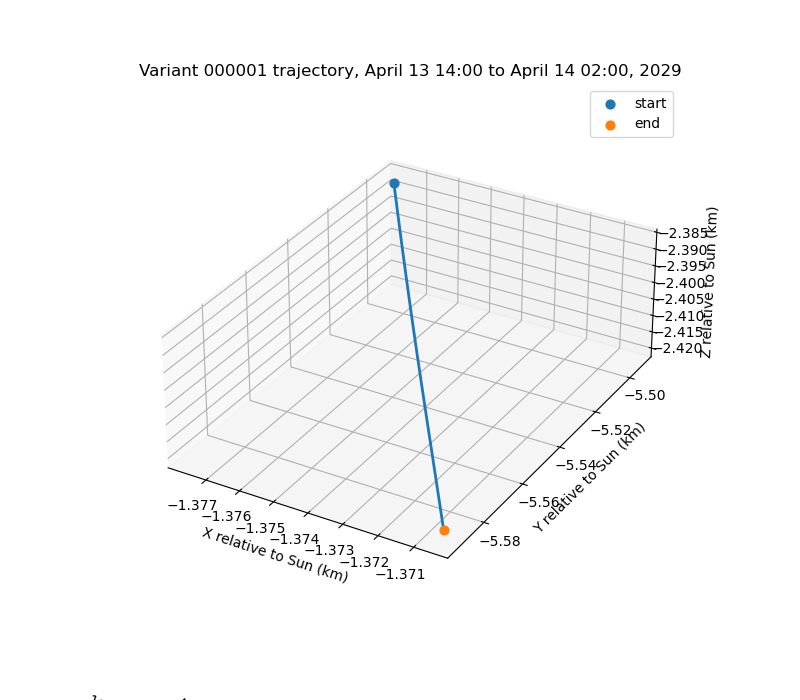

In [4]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    positions_km[:, 0],
    positions_km[:, 1],
    positions_km[:, 2],
    linewidth=2,
)
ax.scatter(
    positions_km[0, 0],
    positions_km[0, 1],
    positions_km[0, 2],
    label="start",
    s=40,
)
ax.scatter(
    positions_km[-1, 0],
    positions_km[-1, 1],
    positions_km[-1, 2],
    label="end",
    s=40,
)

ranges = np.ptp(positions_km, axis=0)
ax.set_box_aspect(ranges)
ax.set_xlabel("X relative to Sun (km)")
ax.set_ylabel("Y relative to Sun (km)")
ax.set_zlabel("Z relative to Sun (km)")
ax.set_title("Variant 000001 trajectory, April 13 14:00 to April 14 02:00, 2029")
ax.legend()
plt.show()

## Overlay All Variants

Plot all variant trajectories over the same time window with one shared color.

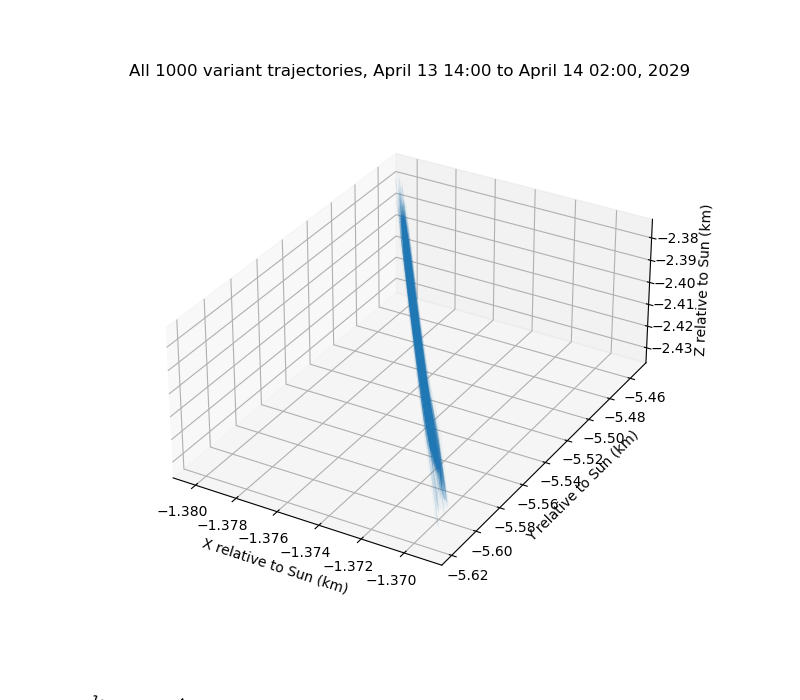

In [5]:
spice.unload(str(FIRST_VARIANT_KERNEL))

variant_kernel_paths = sorted(KERNEL_DIR.glob("*.bsp"))
num_variants_to_plot = len(variant_kernel_paths)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
all_positions_km = []

for kernel_path in variant_kernel_paths:
    spice.furnsh(str(kernel_path))
    object_ids = sorted(spice.spkobj(str(kernel_path)))
    target_id = str(object_ids[0])

    positions_km, light_times = spice.spkpos(
        target_id,
        times_et,
        "J2000",
        "NONE",
        "SUN",
    )
    positions_km = np.asarray(positions_km)
    spice.unload(str(kernel_path))

    all_positions_km.append(positions_km)

    ax.plot(
        positions_km[:, 0],
        positions_km[:, 1],
        positions_km[:, 2],
        color="tab:blue",
        alpha=0.08,
        linewidth=0.5,
    )

all_positions_km = np.concatenate(all_positions_km, axis=0)
ranges = np.ptp(all_positions_km, axis=0)
ax.set_box_aspect(ranges)
ax.set_xlabel("X relative to Sun (km)")
ax.set_ylabel("Y relative to Sun (km)")
ax.set_zlabel("Z relative to Sun (km)")
ax.set_title(f"All {num_variants_to_plot} variant trajectories, April 13 14:00 to April 14 02:00, 2029")
plt.show()

## Trajectory Vector PCA

Flatten each April 13 14:00 to April 14 02:00 trajectory into one vector, then run PCA across variants.

Trajectory tensor shape (variants, samples, xyz): (1000, 49, 3)
Trajectory vector matrix shape (variants, samples * xyz): (1000, 147)
First 5 explained variance ratios: [9.93255524e-01 3.87724118e-03 1.52250718e-03 1.15828130e-03
 1.54491824e-04]


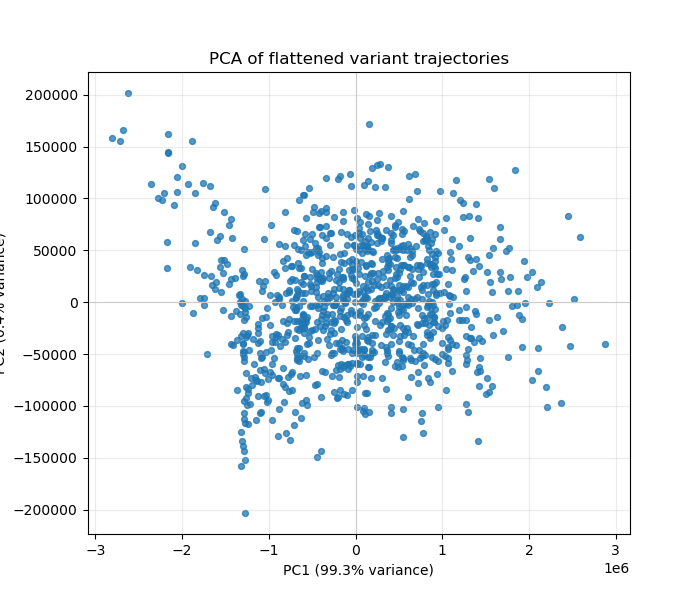

In [6]:
trajectory_positions_km = []
trajectory_variant_ids = []

for kernel_path in variant_kernel_paths:
    spice.furnsh(str(kernel_path))
    object_ids = sorted(spice.spkobj(str(kernel_path)))
    target_id = str(object_ids[0])

    positions_km, light_times = spice.spkpos(
        target_id,
        times_et,
        "J2000",
        "NONE",
        "SUN",
    )
    trajectory_positions_km.append(np.asarray(positions_km, dtype=float))
    trajectory_variant_ids.append(kernel_path.stem)

    spice.unload(str(kernel_path))

trajectory_positions_km = np.asarray(trajectory_positions_km)
trajectory_vectors = trajectory_positions_km.reshape(trajectory_positions_km.shape[0], -1)
trajectory_mean_vector = trajectory_vectors.mean(axis=0)
centered_trajectory_vectors = trajectory_vectors - trajectory_mean_vector

# PCA by SVD: rows are variants, columns are flattened trajectory coordinates.
u, singular_values, vt = np.linalg.svd(centered_trajectory_vectors, full_matrices=False)
trajectory_pca_scores = u * singular_values
trajectory_pca_components = vt
trajectory_pca_variance = (singular_values ** 2) / (trajectory_vectors.shape[0] - 1)
trajectory_pca_explained_variance_ratio = trajectory_pca_variance / trajectory_pca_variance.sum()

print("Trajectory tensor shape (variants, samples, xyz):", trajectory_positions_km.shape)
print("Trajectory vector matrix shape (variants, samples * xyz):", trajectory_vectors.shape)
print("First 5 explained variance ratios:", trajectory_pca_explained_variance_ratio[:5])

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    trajectory_pca_scores[:, 0],
    trajectory_pca_scores[:, 1],
    s=18,
    alpha=0.75,
)
ax.axhline(0, color="0.8", linewidth=0.8)
ax.axvline(0, color="0.8", linewidth=0.8)
ax.set_xlabel(f"PC1 ({trajectory_pca_explained_variance_ratio[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({trajectory_pca_explained_variance_ratio[1]:.1%} variance)")
ax.set_title("PCA of flattened variant trajectories")
ax.grid(True, alpha=0.25)
plt.show()

Streamline variability plots are useful when the ensemble contains multiple distinguishable flow patterns. In this asteroid case, however, the ensemble is dominated by a narrow, continuous uncertainty bundle. Therefore, the more relevant visual task is not cluster identification, but identifying and tracking high-density regions inside the uncertainty envelope.

Trajectory tensor shape: (1000, 49, 3)
PC1 explained variance: 99.3256%
PC2 explained variance: 0.3877%


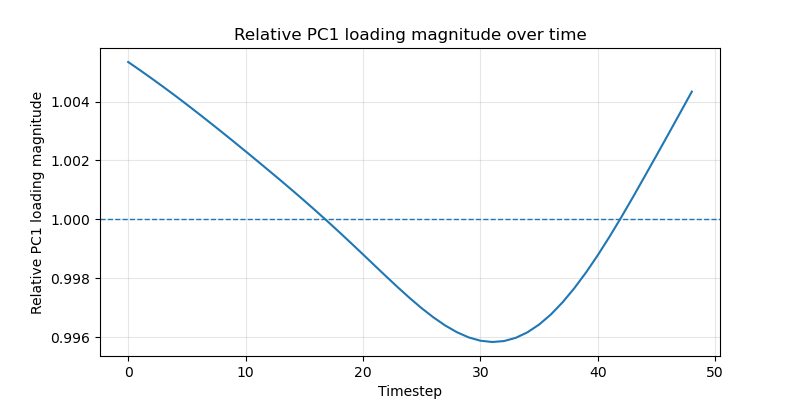

Relative range: 0.009510328523317277


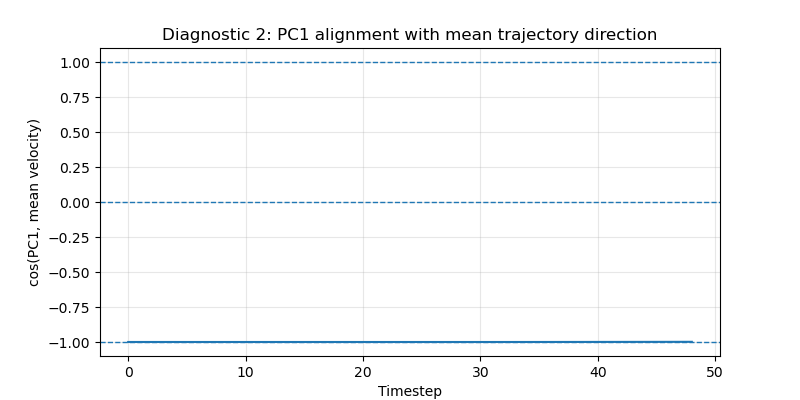

Mean PC1/velocity alignment: -0.9998
Mean absolute PC1/velocity alignment: 0.9998


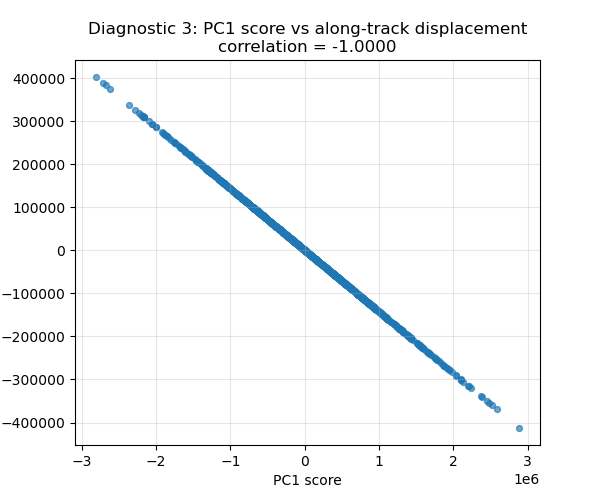

Correlation between PC1 score and mean along-track displacement: -1.0000


In [7]:
# ============================================================
# PC1 diagnostics for SVD/PCA trajectory analysis
#
# Assumes these variables already exist:
#   trajectory_positions_km: shape (N, T, 3)
#   trajectory_vectors: shape (N, T*3)
#   trajectory_mean_vector: shape (T*3,)
#   trajectory_pca_scores: shape (N, num_pcs)
#   trajectory_pca_components: shape (num_pcs, T*3)
#   trajectory_pca_explained_variance_ratio
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

traj = trajectory_positions_km
N, T, D = traj.shape
assert D == 3, f"Expected trajectory_positions_km to have shape (N, T, 3), got {traj.shape}"

# Mean trajectory in physical space
mean_traj = trajectory_mean_vector.reshape(T, 3)

# PC1 loading vector reshaped back into trajectory coordinates
pc1_vec = trajectory_pca_components[0]        # shape: (T * 3,)
pc1_traj = pc1_vec.reshape(T, 3)              # shape: (T, 3)

# PC1 scores, one value per trajectory variant
pc1_scores = trajectory_pca_scores[:, 0]

print("Trajectory tensor shape:", traj.shape)
print(f"PC1 explained variance: {trajectory_pca_explained_variance_ratio[0]:.4%}")
print(f"PC2 explained variance: {trajectory_pca_explained_variance_ratio[1]:.4%}")

# ------------------------------------------------------------
# Diagnostic 1: PC1 loading magnitude over time
# ------------------------------------------------------------
# This shows which timesteps contribute most strongly to PC1.
# If it increases near the end, PC1 mainly captures late-window divergence.

pc1_magnitude = np.linalg.norm(pc1_traj, axis=1)

plt.figure(figsize=(8, 4))
plt.plot(pc1_magnitude / pc1_magnitude.mean())
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.xlabel("Timestep")
plt.ylabel("Relative PC1 loading magnitude")
plt.title("Relative PC1 loading magnitude over time")
plt.grid(alpha=0.3)
plt.show()

print("Relative range:",
      (pc1_magnitude.max() - pc1_magnitude.min()) / pc1_magnitude.mean())

# ------------------------------------------------------------
# Diagnostic 2: PC1 alignment with mean trajectory velocity
# ------------------------------------------------------------
# If this is near +1 or -1, PC1 is mostly along-track.
# If this is near 0, PC1 is mostly cross-track.

velocity = np.gradient(mean_traj, axis=0)  # approximate local tangent direction
velocity_norm = np.linalg.norm(velocity, axis=1, keepdims=True)
velocity_unit = velocity / np.maximum(velocity_norm, 1e-12)

pc1_norm = np.linalg.norm(pc1_traj, axis=1, keepdims=True)
pc1_unit = pc1_traj / np.maximum(pc1_norm, 1e-12)

alignment = np.sum(pc1_unit * velocity_unit, axis=1)

plt.figure(figsize=(8, 4))
plt.plot(alignment)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.axhline(-1.0, linestyle="--", linewidth=1)
plt.xlabel("Timestep")
plt.ylabel("cos(PC1, mean velocity)")
plt.title("Diagnostic 2: PC1 alignment with mean trajectory direction")
plt.grid(alpha=0.3)
plt.show()

print(f"Mean PC1/velocity alignment: {np.mean(alignment):.4f}")
print(f"Mean absolute PC1/velocity alignment: {np.mean(np.abs(alignment)):.4f}")

# ------------------------------------------------------------
# Diagnostic 3: PC1 score vs mean along-track displacement
# ------------------------------------------------------------
# If this correlation is close to +1 or -1, PC1 is basically
# an along-track displacement / timing mode.

displacements = traj - mean_traj[None, :, :]  # shape: (N, T, 3)

# Project displacement of each variant onto local mean velocity direction
along_track = np.sum(displacements * velocity_unit[None, :, :], axis=2)  # shape: (N, T)

# Summarize each variant by its average along-track displacement
mean_along_track = along_track.mean(axis=1)

corr_along = np.corrcoef(pc1_scores, mean_along_track)[0, 1]

plt.figure(figsize=(6, 5))
plt.scatter(pc1_scores, mean_along_track, s=18, alpha=0.65)
plt.xlabel("PC1 score")
plt.ylabel("Mean along-track displacement (km)")
plt.title(
    "Diagnostic 3: PC1 score vs along-track displacement\n"
    f"correlation = {corr_along:.4f}"
)
plt.grid(alpha=0.3)
plt.show()

print(f"Correlation between PC1 score and mean along-track displacement: {corr_along:.4f}")

PC1 is almost perfectly anti-aligned with the mean trajectory direction. The PCA plot is probably arranging trajectories mostly by how far ahead or behind they are along the track. (time lag) Around impact, the trajectories are almost the same curve, and the largest difference is that variants are slightly ahead/behind along that curve.

## Cleanup

Run this when you are done or before restarting the analysis.

In [8]:
spice.kclear()
print("SPICE kernels cleared.")

SPICE kernels cleared.
